<a href="https://colab.research.google.com/github/rajeev198886/SKS-Data-Science-Internship-2026/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset.csv.csv to Telco_Customer_Churn_Dataset.csv (1).csv


In [3]:
data = pd.read_csv("Telco_Customer_Churn_Dataset.csv (1).csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [6]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].mean())

In [7]:
data["Tenure_Group"] = pd.cut(
    data["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12","13-24","25-48","49-72"]
)

data["Tenure_Group"].value_counts()

,count
Tenure_Group,
49-72,2239
0-12,2175
25-48,1594
13-24,1024


In [8]:
data["Monthly_Group"] = pd.cut(
    data["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=["Low","Medium","High"]
)

data["Monthly_Group"].value_counts()

,count
Monthly_Group,
High,3583
Low,1735
Medium,1725


In [9]:
data["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


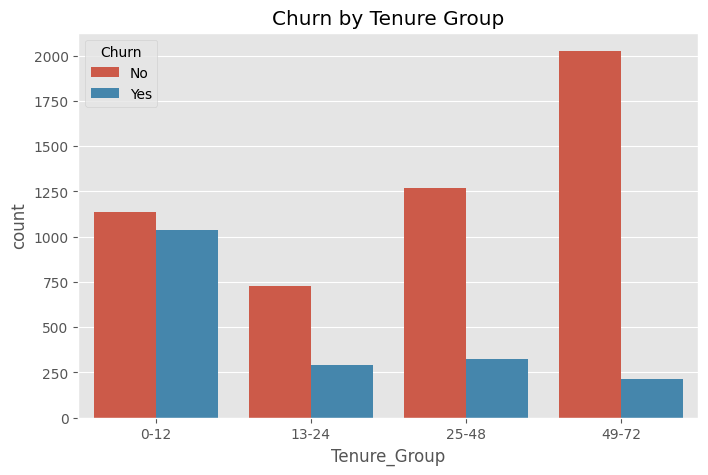

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Tenure_Group",
    hue="Churn",
    data=data
)

plt.title("Churn by Tenure Group")

plt.show()

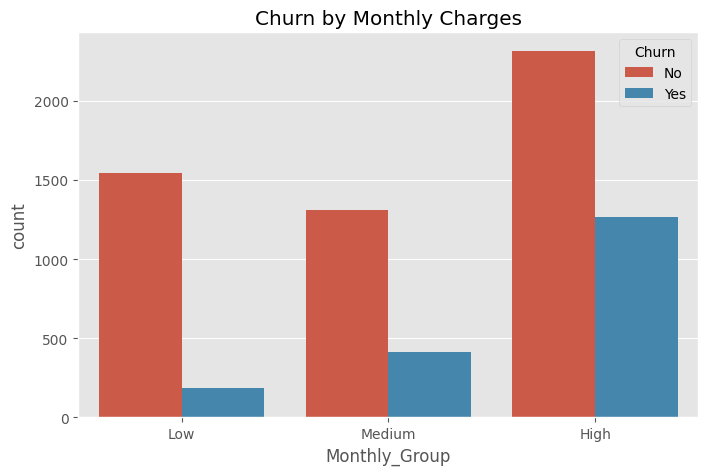

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Monthly_Group",
    hue="Churn",
    data=data
)

plt.title("Churn by Monthly Charges")

plt.show()

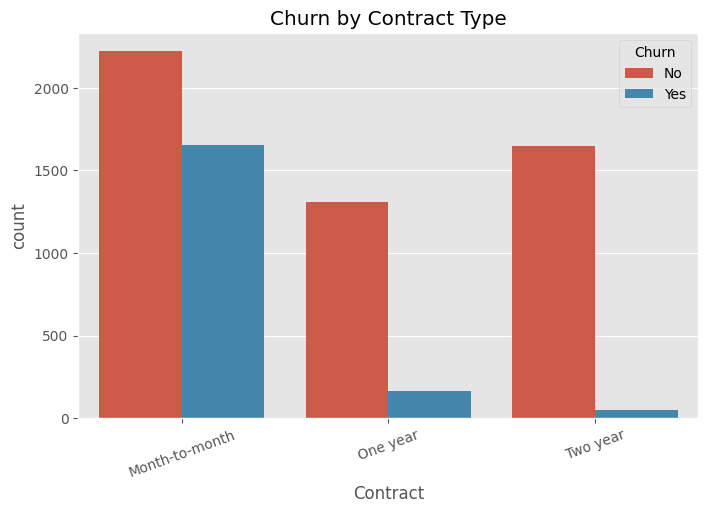

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=data
)

plt.title("Churn by Contract Type")

plt.xticks(rotation=20)

plt.show()

In [13]:
high_value = data[
    (data["tenure"] > 24) &
    (data["MonthlyCharges"] > 70)
]

high_value.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Monthly_Group
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,25-48,High
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No,49-72,High
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,49-72,High
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No,25-48,High
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No,49-72,High


In [14]:
at_risk = high_value[
    high_value["Churn"] == "Yes"
]

at_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Monthly_Group
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,25-48,High
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,49-72,High
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,25-48,High
38,5380-WJKOV,Male,0,No,No,34,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,106.35,3549.25,Yes,25-48,High
99,4598-XLKNJ,Female,1,Yes,No,25,Yes,No,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.50,2514.50,Yes,25-48,High


In [15]:
print("Total High-Value Customers :", len(high_value))

print("High-Value Customers at Risk :", len(at_risk))

Total High-Value Customers : 2230
High-Value Customers at Risk : 455


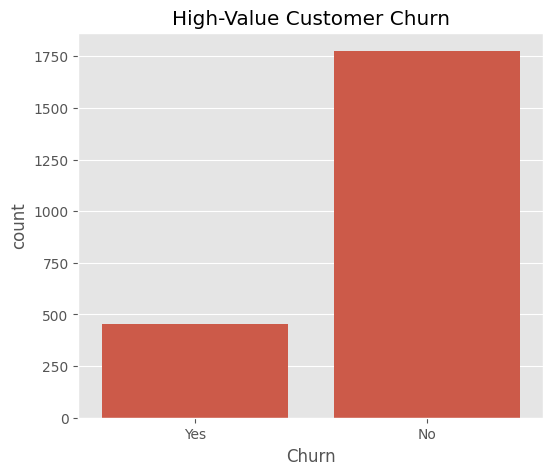

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Churn",
    data=high_value
)

plt.title("High-Value Customer Churn")

plt.show()

In [17]:
at_risk[[
    "gender",
    "tenure",
    "MonthlyCharges",
    "Contract",
    "PaymentMethod",
    "Churn"
]].head(10)

,gender,tenure,MonthlyCharges,Contract,PaymentMethod,Churn
8,Female,28,104.80,Month-to-month,Electronic check,Yes
13,Male,49,103.70,Month-to-month,Bank transfer (automatic),Yes
26,Male,47,99.35,Month-to-month,Electronic check,Yes
38,Male,34,106.35,Month-to-month,Electronic check,Yes
99,Female,25,98.50,Month-to-month,Electronic check,Yes
104,Male,68,110.00,Two year,Bank transfer (automatic),Yes
110,Male,55,96.75,Month-to-month,Electronic check,Yes
113,Female,37,76.50,Month-to-month,Electronic check,Yes
126,Female,27,78.05,Month-to-month,Electronic check,Yes
173,Female,53,94.85,One year,Bank transfer (automatic),Yes


In [18]:
at_risk.to_csv("High_Value_Customers.csv", index=False)

print("File Saved Successfully")

File Saved Successfully
